In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)

## Sentiment Analysis using IMDB Movie Reviews
Business Problem

A movie streaming company wants to automatically classify user reviews as:

 Positive Review or  Negative Review

In [2]:
from tensorflow.keras.datasets import imdb

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

"""We keep only the 10,000 most frequent words.

Less frequent words are replaced with a special "unknown" token.

Benefits:

Faster training
Lower memory usage
Less noise """

'We keep only the 10,000 most frequent words.\n\nLess frequent words are replaced with a special "unknown" token.\n\nBenefits:\n\nFaster training\nLower memory usage\nLess noise '

In [3]:
X_train

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [4]:
X_test

array([list([1, 591, 202, 14, 31, 6, 717, 10, 10, 2, 2, 5, 4, 360, 7, 4, 177, 5760, 394, 354, 4, 123, 9, 1035, 1035, 1035, 10, 10, 13, 92, 124, 89, 488, 7944, 100, 28, 1668, 14, 31, 23, 27, 7479, 29, 220, 468, 8, 124, 14, 286, 170, 8, 157, 46, 5, 27, 239, 16, 179, 2, 38, 32, 25, 7944, 451, 202, 14, 6, 717]),
       list([1, 14, 22, 3443, 6, 176, 7, 5063, 88, 12, 2679, 23, 1310, 5, 109, 943, 4, 114, 9, 55, 606, 5, 111, 7, 4, 139, 193, 273, 23, 4, 172, 270, 11, 7216, 2, 4, 8463, 2801, 109, 1603, 21, 4, 22, 3861, 8, 6, 1193, 1330, 10, 10, 4, 105, 987, 35, 841, 2, 19, 861, 1074, 5, 1987, 2, 45, 55, 221, 15, 670, 5304, 526, 14, 1069, 4, 405, 5, 2438, 7, 27, 85, 108, 131, 4, 5045, 5304, 3884, 405, 9, 3523, 133, 5, 50, 13, 104, 51, 66, 166, 14, 22, 157, 9, 4, 530, 239, 34, 8463, 2801, 45, 407, 31, 7, 41, 3778, 105, 21, 59, 299, 12, 38, 950, 5, 4521, 15, 45, 629, 488, 2733, 127, 6, 52, 292, 17, 4, 6936, 185, 132, 1988, 5304, 1799, 488, 2693, 47, 6, 392, 173, 4, 2, 4378, 270, 2352, 4, 1500, 7, 

In [5]:
print(X_train.shape)
#25000 reviews

(25000,)


In [6]:
print(y_train.shape)
#25000 labels

(25000,)


In [7]:
""" These are word indices, not the original text.
TensorFlow has already converted words to integers."""
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [8]:
print(np.unique(y_train))

[0 1]


In [9]:
print(len(X_train[0]))
print(len(X_train[1]))
"""Sequence Lengths
Reviews have different lengths."""

218
189


'Sequence Lengths\nReviews have different lengths.'

In [10]:
"""Why Padding?
Reviews have different lengths.
Neural networks require inputs of the same length.
We pad shorter reviews with zeros.
 """

from tensorflow.keras.preprocessing.sequence import pad_sequences

max_length = 200

X_train = pad_sequences(
    X_train,
    maxlen=max_length
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length
)

In [11]:
#rnn building 
model = Sequential()

In [12]:
#embedding layers
model.add(
    Embedding(
        input_dim=10000,
        output_dim=64,
        input_length=max_length
    )
)
"""Converts each word ID into a dense vector.

Instead of

movie

523

Embedding learns something like

movie

[0.23, -0.54, 0.88, ...]

This allows the model to learn semantic relationships between words. """

d:\Deep-learning-revision-\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


'Converts each word ID into a dense vector.\n\nInstead of\n\nmovie\n\n523\n\nEmbedding learns something like\n\nmovie\n\n[0.23, -0.54, 0.88, ...]\n\nThis allows the model to learn semantic relationships between words. '

In [13]:
#SimpleRNN Layer
model.add(
    SimpleRNN(32)
)

In [14]:
#Dense layer
Dense(
    16,
    activation='relu'
)

<Dense name=dense, built=False>

In [15]:
#dropout layer
model.add(
    Dropout(0.5)
)

In [16]:
#Output Layer
model.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

In [17]:
#Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
#EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [19]:
#Checkpoint
checkpoint = ModelCheckpoint(
    "best_rnn.keras",
    save_best_only=True,
    monitor="val_loss"
)

In [20]:
#Train
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=3,
    batch_size=64,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.6227 - loss: 0.6322 - val_accuracy: 0.6476 - val_loss: 0.6260
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.7513 - loss: 0.5173 - val_accuracy: 0.7766 - val_loss: 0.4733
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - accuracy: 0.8913 - loss: 0.2823 - val_accuracy: 0.8228 - val_loss: 0.4377


In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,929,413 (7.36 MB)

 Trainable params: 643,137 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,286,276 (4.91 MB)

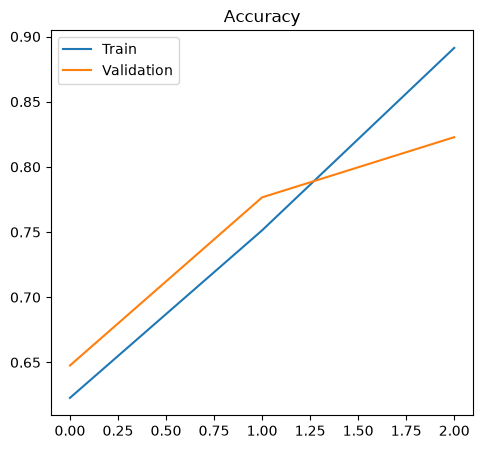

In [22]:
#training and validation accuracy both should be increasing 
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

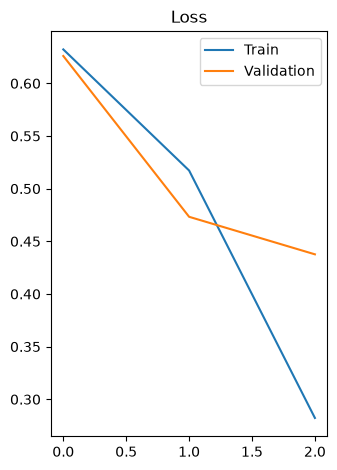

In [23]:
#loss should be decreasing for both training and validation loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
#evaluate the model on the test set
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print(test_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8265 - loss: 0.4265
0.8265200257301331


In [25]:
#predict probabilities
predictions = model.predict(X_test[:5])

print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step
[[0.05698704]
 [0.9853476 ]
 [0.59738433]
 [0.97932833]
 [0.90157616]]


In [26]:
#Convert to labels
predicted_labels = (predictions > 0.5).astype(int)

print(predicted_labels)

[[0]
 [1]
 [1]
 [1]
 [1]]


In [27]:
#Compare with the true labels
print("Actual :", y_test[:5])
print("Predicted :", predicted_labels.flatten())

Actual : [0 1 1 0 1]
Predicted : [0 1 1 1 1]


In [28]:
#valuate with Classification Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
[[ 9327  3173]
 [ 1164 11336]]
              precision    recall  f1-score   support

           0       0.89      0.75      0.81     12500
           1       0.78      0.91      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.84      0.83      0.83     25000
weighted avg       0.84      0.83      0.83     25000

